### Evaluation file of generated segmentations


In [5]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy import ndimage


In [52]:
# LOAD SEGMENTATIONS
img_path       = r"data\LUNDPROBE\ExtendedSamples\newAcq_36aad7805ccb4419\MR_StorT2\image.nii.gz"
pred_mask_path = r"C:\Users\20202310\Desktop\MSc scriptie\MSc_Graduation_Project\data\LUNDPROBE\ExtendedSamples\newAcq_36aad7805ccb4419\MR_StorT2\SAM_OUTPUT\bald_prediction.nii.gz"
gt_mask_path   = r"C:\Users\20202310\Desktop\MSc scriptie\MSc_Graduation_Project\data\LUNDPROBE\ExtendedSamples\newAcq_36aad7805ccb4419\MR_StorT2\mask_CTVT_427.nii.gz"

img_itk       = sitk.ReadImage(img_path)
pred_mask_itk = sitk.ReadImage(pred_mask_path)
gt_mask_itk   = sitk.ReadImage(gt_mask_path)

# Convert to numpy arrays — shape is (z, y, x)
img       = sitk.GetArrayFromImage(img_itk).astype(np.float32)
pred_mask = (sitk.GetArrayFromImage(pred_mask_itk) > 0).astype(np.uint8)
gt_mask   = (sitk.GetArrayFromImage(gt_mask_itk)   > 0).astype(np.uint8)

# Voxel spacing in mm — needed for physical-space metrics
spacing_xyz = img_itk.GetSpacing()          # (x, y, z)
spacing_zyx = (spacing_xyz[2], spacing_xyz[1], spacing_xyz[0])

print(f"Image shape   : {img.shape}")
print(f"Pred shape    : {pred_mask.shape}")
print(f"GT shape      : {gt_mask.shape}")
print(f"Spacing (zyx) : {spacing_zyx} mm")
print(f"Pred voxels   : {pred_mask.sum()}")
print(f"GT voxels     : {gt_mask.sum()}")


Image shape   : (88, 1024, 1024)
Pred shape    : (88, 1024, 1024)
GT shape      : (88, 1024, 1024)
Spacing (zyx) : (2.5, 0.46880000829696655, 0.46880000829696655) mm
Pred voxels   : 113818
GT voxels     : 113639


In [53]:
import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt, center_of_mass


def get_surface(mask):
    return mask & ~binary_erosion(mask)


def surface_distances(pred, gt, spacing):
    pred_surf = get_surface(pred)
    gt_surf = get_surface(gt)

    dt_gt = distance_transform_edt(~gt_surf, sampling=spacing)
    dt_pred = distance_transform_edt(~pred_surf, sampling=spacing)

    d_pred_to_gt = dt_gt[pred_surf]
    d_gt_to_pred = dt_pred[gt_surf]

    return d_pred_to_gt, d_gt_to_pred, pred_surf, gt_surf


def compute_metrics(pred, gt, spacing=(1.0, 1.0, 1.0), surface_dice_tol=2.0, apl_tol=0.0):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    d_pred_to_gt, d_gt_to_pred, pred_surf, gt_surf = surface_distances(pred, gt, spacing)

    # HD95
    hd95 = np.percentile(np.concatenate([d_pred_to_gt, d_gt_to_pred]), 95)

    # MSD and ASSD
    msd = np.mean(d_pred_to_gt)
    assd = (np.mean(d_pred_to_gt) + np.mean(d_gt_to_pred)) / 2

    # Surface Dice
    surface_dice = (
        np.sum(d_pred_to_gt <= surface_dice_tol) + np.sum(d_gt_to_pred <= surface_dice_tol)
    ) / (np.sum(pred_surf) + np.sum(gt_surf))

    # Centroid distance
    c_pred = np.array(center_of_mass(pred)) * np.array(spacing)
    c_gt = np.array(center_of_mass(gt)) * np.array(spacing)
    centroid_dist = np.linalg.norm(c_pred - c_gt)

    # Volume difference
    voxel_volume = np.prod(spacing)
    pred_vol = np.sum(pred) * voxel_volume
    gt_vol = np.sum(gt) * voxel_volume
    abs_vol_diff = abs(pred_vol - gt_vol)
    rel_vol_diff = 100 * (pred_vol - gt_vol) / gt_vol if gt_vol > 0 else np.nan

    # Very simple APL-like proxy
    apl_like = np.sum(d_gt_to_pred > apl_tol) * np.mean(spacing)

    return {
        "HD95_mm": hd95,
        "MSD_mm": msd,
        "ASSD_mm": assd,
        f"SurfaceDice@{surface_dice_tol}mm": surface_dice,
        "CentroidDistance_mm": centroid_dist,
        "AbsVolumeDifference_mm3": abs_vol_diff,
        "RelativeVolumeDifference_percent": rel_vol_diff,
        f"APL_like@{apl_tol}mm": apl_like,
    }

In [54]:
metrics = compute_metrics(pred_mask, gt_mask, spacing=spacing_xyz, surface_dice_tol=1.0)

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

HD95_mm: 0.9376
MSD_mm: 0.3924
ASSD_mm: 0.3707
SurfaceDice@1.0mm: 0.9734
CentroidDistance_mm: 2.3318
AbsVolumeDifference_mm3: 98.3486
RelativeVolumeDifference_percent: 0.1575
APL_like@0.0mm: 13468.5169


In [31]:
# All slice indices in the volume
all_slices = np.arange(pred_mask.shape[0])

# Slices where either GT or prediction has any mask voxel
occupied_slices = np.where(np.logical_or(pred_mask, gt_mask).any(axis=(1, 2)))[0]

# Optional: split by source
pred_slices = np.where(pred_mask.any(axis=(1, 2)))[0]
gt_slices = np.where(gt_mask.any(axis=(1, 2)))[0]

print("All slices:", all_slices)
print("Occupied slices (GT or Pred):", occupied_slices)
print("Pred-only occupied slices:", pred_slices)
print("GT-only occupied slices:", gt_slices)

All slices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87]
Occupied slices (GT or Pred): [30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50]
Pred-only occupied slices: [30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50]
GT-only occupied slices: [32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]


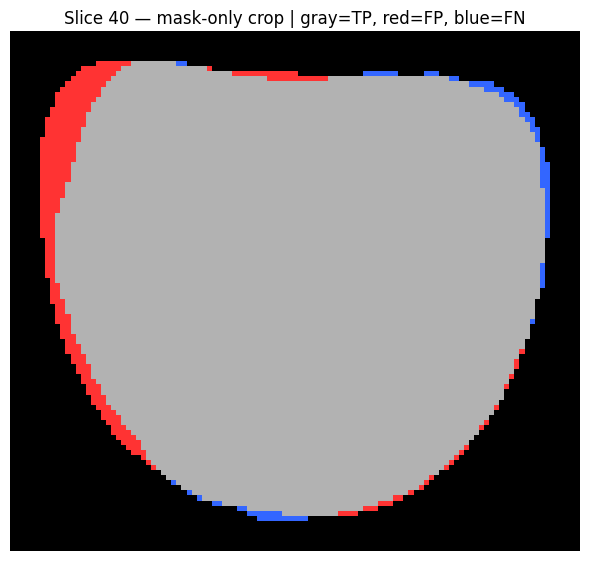

In [48]:
# VISUALISATION — mask-only crop + FP/FN color map

# Set to an integer slice index to choose manually, or keep None for auto-selection
selected_slice = 40

occupied = np.where(np.logical_or(pred_mask, gt_mask).any(axis=(1, 2)))[0]
if len(occupied) == 0:
    raise ValueError("Both prediction and GT masks are empty.")

if selected_slice is None:
    sl = int(occupied[len(occupied) // 2])
else:
    sl = int(selected_slice)
    if sl < 0 or sl >= pred_mask.shape[0]:
        raise ValueError(f"selected_slice={sl} is out of bounds [0, {pred_mask.shape[0]-1}]")

pred_sl = pred_mask[sl].astype(bool)
gt_sl = gt_mask[sl].astype(bool)

tp = pred_sl & gt_sl
fp = pred_sl & ~gt_sl
fn = ~pred_sl & gt_sl

# Crop tightly around the union of GT and prediction for this slice
union = pred_sl | gt_sl
if not union.any():
    raise ValueError(f"Slice {sl} has no mask voxels in GT or prediction.")

ys, xs = np.where(union)
pad = 6
y0 = max(int(ys.min()) - pad, 0)
y1 = min(int(ys.max()) + pad + 1, union.shape[0])
x0 = max(int(xs.min()) - pad, 0)
x1 = min(int(xs.max()) + pad + 1, union.shape[1])

tp_c = tp[y0:y1, x0:x1]
fp_c = fp[y0:y1, x0:x1]
fn_c = fn[y0:y1, x0:x1]

# Build mask-only RGB map (background black)
mask_rgb = np.zeros((y1 - y0, x1 - x0, 3), dtype=np.float32)
mask_rgb[tp_c] = [0.7, 0.7, 0.7]   # TP = gray
mask_rgb[fp_c] = [1.0, 0.2, 0.2]   # FP = red
mask_rgb[fn_c] = [0.2, 0.4, 1.0]   # FN = blue

plt.figure(figsize=(6, 6))
plt.imshow(mask_rgb, origin="lower")
plt.title(f"Slice {sl} — mask-only crop | gray=TP, red=FP, blue=FN")
plt.axis("off")
plt.tight_layout()
plt.show()